    # FIFA World Cup 2026 — Tournament Simulator
### Monte Carlo Simulation of the Full Tournament

**Goal:** Simulate the entire WC 2026 tournament 10,000+ times to estimate each team's probability of reaching every stage (R32, R16, QF, SF, Final, Winner).

**Method:**
1. Simulate all group stage matches using our Elo-based match predictor
2. Determine group standings (top 2 + 8 best 3rd-place teams advance)
3. Populate the official knockout bracket
4. Simulate knockout matches through to the final
5. Repeat 10,000 times and aggregate results

**Inputs:**
- FIFA Elo rankings (`fifa_rankings.py`)
- Official groups & bracket (`wc_2026_schedule.py`)
- Match prediction functions (`match_predictor.py`)


## 1. Imports & Setup


In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')
import sys
sys.path.insert(0, '../src/data_collection')
sys.path.insert(0, '../src/prediction')

%matplotlib inline

from fifa_rankings import FIFA_RANKINGS
from wc_2026_schedule import GROUPS, LEFT_BRACKET, RIGHT_BRACKET
from match_predictor import elo_expected_score, predict_match, predict_goals

# Number of simulations
N_SIMS = 10000

print(f"Loaded {len(FIFA_RANKINGS)} team rankings")
print(f"Loaded {len(GROUPS)} groups")
print(f"Will run {N_SIMS:,} simulations")


Loaded 50 team rankings
Loaded 12 groups
Will run 10,000 simulations


## 2. Helper Functions

### 2.1 Simulate a Single Match
Given two teams and their Elo ratings, simulate a match result.


In [98]:
def simulate_match(elo_a, elo_b, knockout=False):
    """
    Simulate a single match outcome.
    
    Returns:
        For group stage: (goals_a, goals_b)
        For knockout: (winner_index, goals_a, goals_b)
            winner_index: 0 = team A wins, 1 = team B wins
    """
    p_win_a, p_draw, p_win_b = predict_match(elo_a, elo_b, knockout=knockout)
    
    if knockout:
        # No draws — team A advances with probability p_win_a
        if np.random.random() < p_win_a:
            # Team A advances
            xg_a, xg_b = predict_goals(elo_a, elo_b)
            goals_a = max(np.random.poisson(xg_a), 1)  # winner scores at least 1
            goals_b = np.random.poisson(xg_b * 0.8)
            if goals_a <= goals_b:
                goals_a = goals_b + 1  # ensure winner has more
            return 0, goals_a, goals_b
        else:
            xg_a, xg_b = predict_goals(elo_a, elo_b)
            goals_b = max(np.random.poisson(xg_b), 1)
            goals_a = np.random.poisson(xg_a * 0.8)
            if goals_b <= goals_a:
                goals_b = goals_a + 1
            return 1, goals_a, goals_b
    else:
        # Group stage — draws possible
        rand = np.random.random()
        xg_a, xg_b = predict_goals(elo_a, elo_b)
        
        if rand < p_win_a:
            # Team A wins
            goals_a = max(np.random.poisson(xg_a), 1)
            goals_b = np.random.poisson(xg_b * 0.7)
            if goals_a <= goals_b:
                goals_a = goals_b + 1
            return goals_a, goals_b
        elif rand < p_win_a + p_draw:
            # Draw
            goals = np.random.poisson((xg_a + xg_b) / 2 * 0.8)
            return goals, goals
        else:
            # Team B wins
            goals_b = max(np.random.poisson(xg_b), 1)
            goals_a = np.random.poisson(xg_a * 0.7)
            if goals_b <= goals_a:
                goals_b = goals_a + 1
            return goals_a, goals_b

# Quick test
np.random.seed(42)
for _ in range(5):
    g_a, g_b = simulate_match(FIFA_RANKINGS["Spain"], FIFA_RANKINGS["Cabo Verde"])
    print(f"  Spain {g_a} - {g_b} Cabo Verde")
print()
for _ in range(5):
    w, g_a, g_b = simulate_match(FIFA_RANKINGS["Spain"], FIFA_RANKINGS["Argentina"], knockout=True)
    winner = "Spain" if w == 0 else "Argentina"
    print(f"  Spain {g_a} - {g_b} Argentina → {winner} advances")


  Spain 3 - 0 Cabo Verde
  Spain 3 - 2 Cabo Verde
  Spain 1 - 0 Cabo Verde
  Spain 2 - 0 Cabo Verde
  Spain 2 - 0 Cabo Verde

  Spain 1 - 2 Argentina → Argentina advances
  Spain 3 - 0 Argentina → Spain advances
  Spain 1 - 2 Argentina → Argentina advances
  Spain 1 - 2 Argentina → Argentina advances
  Spain 5 - 6 Argentina → Argentina advances


### 2.2 Simulate Group Stage


In [99]:
def simulate_group(group_name, teams, elo_dict):
    """
    Simulate all 6 matches in a group.
    Returns sorted standings: [(team, points, gd, gf), ...]
    """
    stats = {t: {"pts": 0, "gd": 0, "gf": 0, "ga": 0} for t in teams}
    
    # Each team plays the other 3 (6 matches total)
    for i in range(len(teams)):
        for j in range(i + 1, len(teams)):
            a, b = teams[i], teams[j]
            elo_a = elo_dict.get(a, 1400)
            elo_b = elo_dict.get(b, 1400)
            
            goals_a, goals_b = simulate_match(elo_a, elo_b, knockout=False)
            
            # Update stats
            stats[a]["gf"] += goals_a
            stats[a]["ga"] += goals_b
            stats[a]["gd"] += goals_a - goals_b
            stats[b]["gf"] += goals_b
            stats[b]["ga"] += goals_a
            stats[b]["gd"] += goals_b - goals_a
            
            if goals_a > goals_b:
                stats[a]["pts"] += 3
            elif goals_a == goals_b:
                stats[a]["pts"] += 1
                stats[b]["pts"] += 1
            else:
                stats[b]["pts"] += 3
    
    # Sort: points → goal difference → goals scored → random tiebreak
    standings = [(t, s["pts"], s["gd"], s["gf"]) for t, s in stats.items()]
    standings.sort(key=lambda x: (x[1], x[2], x[3], np.random.random()), reverse=True)
    
    return standings

# Test one group
np.random.seed(42)
test = simulate_group("H", GROUPS["H"], FIFA_RANKINGS)
print("Group H test simulation:")
for rank, (team, pts, gd, gf) in enumerate(test, 1):
    print(f"  {rank}. {team:<20} {pts} pts  GD: {gd:+d}  GF: {gf}")


Group H test simulation:
  1. Spain                9 pts  GD: +5  GF: 7
  2. Uruguay              4 pts  GD: +0  GF: 2
  3. Saudi Arabia         2 pts  GD: -1  GF: 3
  4. Cabo Verde           1 pts  GD: -4  GF: 0


### 2.3 Determine Best 3rd-Place Teams

In the 48-team format, the top 2 from each group (24 teams) plus the **8 best 3rd-place teams** advance to the Round of 32. That's 32 teams total.

We rank all twelve 3rd-place teams by: points → goal difference → goals scored, and take the top 8.


In [100]:
def get_best_third_place(all_standings):
    """
    From 12 group standings, collect all 3rd-place teams,
    rank them, and return the best 8.
    
    Returns:
        qualified_3rds: dict mapping group_letter → 3rd place team name
            (only for the 8 groups whose 3rd place team qualifies)
    """
    third_place = []
    for group_name, standings in all_standings.items():
        team, pts, gd, gf = standings[2]  # 3rd place (index 2)
        third_place.append((group_name, team, pts, gd, gf))
    
    # Sort by pts → gd → gf → random
    third_place.sort(key=lambda x: (x[2], x[3], x[4], np.random.random()), reverse=True)
    
    # Top 8 qualify
    qualified = {entry[0]: entry[1] for entry in third_place[:8]}
    return qualified

print("✅ Best 3rd-place selection function ready")


✅ Best 3rd-place selection function ready


### 2.4 Resolve 3rd-Place Bracket Slots

The bracket has specific slots like `3rd_ABCDF` meaning "the 3rd-place team from one of groups A, B, C, D, or F". Which specific 3rd-place team fills each slot depends on WHICH 8 groups have qualifying 3rd-place teams.

FIFA has a pre-defined lookup table for this, but we'll use a simplified approach: for each bracket slot, pick the highest-ranked qualifying 3rd-place team from the allowed groups.


In [101]:
def resolve_third_place_slots(qualified_3rds, elo_dict):
    """
    Given which 8 groups have qualifying 3rd-place teams,
    assign them to the correct bracket slots.
    
    Each bracket slot specifies which groups it can draw from.
    We assign the best available team to each slot.
    """
    # Bracket slots and their allowed source groups
    # From the official bracket image
    slots = {
        "3rd_ABCDF": list("ABCDF"),
        "3rd_CDFGH": list("CDFGH"),
        "3rd_BEFIJ": list("BEFIJ"),
        "3rd_AEHIJ": list("AEHIJ"),
        "3rd_CEFHI": list("CEFHI"),
        "3rd_EHIJK": list("EHIJK"),
        "3rd_EFGIJ": list("EFGIJ"),
        "3rd_DEIJL": list("DEIJL"),
    }
    
    assigned = {}
    used_groups = set()
    
    # Sort slots by how restrictive they are (fewest options first)
    sorted_slots = sorted(slots.items(), key=lambda x: len([g for g in x[1] if g in qualified_3rds and g not in used_groups]))
    
    # Greedy assignment: for each slot, pick the strongest available team
    for slot_name, allowed_groups in sorted_slots:
        candidates = [(g, qualified_3rds[g]) for g in allowed_groups 
                      if g in qualified_3rds and g not in used_groups]
        
        if candidates:
            # Pick the strongest candidate by Elo
            best = max(candidates, key=lambda x: elo_dict.get(x[1], 1400))
            assigned[slot_name] = best[1]
            used_groups.add(best[0])
        else:
            # Fallback: pick any remaining qualified 3rd
            remaining = [(g, t) for g, t in qualified_3rds.items() if g not in used_groups]
            if remaining:
                best = max(remaining, key=lambda x: elo_dict.get(x[1], 1400))
                assigned[slot_name] = best[1]
                used_groups.add(best[0])
    
    return assigned

print("✅ 3rd-place bracket resolution function ready")


✅ 3rd-place bracket resolution function ready


### 2.5 Simulate Knockout Stage


In [102]:
def simulate_knockout(bracket_matchups, group_results, third_place_assigned, elo_dict):
    """
    Simulate the full knockout stage from R32 to Final.
    
    Parameters:
        bracket_matchups: list of (slot_a, slot_b) tuples
        group_results: dict of group standings
        third_place_assigned: dict mapping slot names to team names
        elo_dict: team → elo rating
    
    Returns:
        results dict with round-by-round winners
    """
    
    def resolve_slot(slot):
        """Convert a bracket slot like '1H' or '2C' to a team name."""
        if slot.startswith("3rd_"):
            return third_place_assigned.get(slot, "Unknown")
        
        position = int(slot[0]) - 1  # 1-indexed to 0-indexed
        group = slot[1]
        standings = group_results[group]
        return standings[position][0]  # team name
    
    def play_knockout_round(matchups, elo_dict):
        """Simulate a round of knockout matches. Returns list of winners."""
        winners = []
        for team_a, team_b in matchups:
            elo_a = elo_dict.get(team_a, 1400)
            elo_b = elo_dict.get(team_b, 1400)
            winner_idx, _, _ = simulate_match(elo_a, elo_b, knockout=True)
            winners.append(team_a if winner_idx == 0 else team_b)
        return winners
    
    # === ROUND OF 32 ===
    r32_matchups = []
    for slot_a, slot_b in bracket_matchups:
        team_a = resolve_slot(slot_a)
        team_b = resolve_slot(slot_b)
        r32_matchups.append((team_a, team_b))
    
    r32_winners = play_knockout_round(r32_matchups, elo_dict)
    
    # === ROUND OF 16 ===
    r16_matchups = [(r32_winners[i], r32_winners[i+1]) for i in range(0, len(r32_winners), 2)]
    r16_winners = play_knockout_round(r16_matchups, elo_dict)
    
    # === QUARTER-FINALS ===
    qf_matchups = [(r16_winners[i], r16_winners[i+1]) for i in range(0, len(r16_winners), 2)]
    qf_winners = play_knockout_round(qf_matchups, elo_dict)
    
    # === SEMI-FINALS ===
    sf_matchups = [(qf_winners[i], qf_winners[i+1]) for i in range(0, len(qf_winners), 2)]
    sf_winners = play_knockout_round(sf_matchups, elo_dict)
    
    # === FINAL ===
    final_winner_idx, _, _ = simulate_match(
        elo_dict.get(sf_winners[0], 1400),
        elo_dict.get(sf_winners[1], 1400),
        knockout=True
    )
    champion = sf_winners[0] if final_winner_idx == 0 else sf_winners[1]
    
    return {
        "r32": [t for pair in r32_matchups for t in pair],  # all 32 teams
        "r16": r32_winners,    # 16 teams
        "qf": r16_winners,     # 8 teams
        "sf": qf_winners,      # 4 teams
        "final": sf_winners,   # 2 teams
        "champion": champion,  # 1 team
    }

print("✅ Full knockout simulation function ready")


✅ Full knockout simulation function ready


## 3. Run Full Tournament Simulation

Now we combine everything: simulate groups → determine 3rd-place qualifiers → populate bracket → simulate knockout → repeat 10,000 times.


In [103]:
def simulate_tournament(elo_dict, n_sims=10000):
    """
    Run n_sims full tournament simulations.
    Returns progress tracker with counts per team per stage.
    """
    # Track how far each team gets
    all_teams = set()
    for teams in GROUPS.values():
        all_teams.update(teams)
    
    progress = {team: defaultdict(int) for team in all_teams}
    
    # Full bracket = left + right
    full_bracket = LEFT_BRACKET + RIGHT_BRACKET
    
    for sim in range(n_sims):
        if (sim + 1) % 2000 == 0:
            print(f"  Simulation {sim + 1:,}/{n_sims:,}...")
        
        # 1. Simulate all 12 groups
        group_results = {}
        for group_name, teams in GROUPS.items():
            standings = simulate_group(group_name, teams, elo_dict)
            group_results[group_name] = standings
        
        # 2. Determine which 3rd-place teams qualify
        qualified_3rds = get_best_third_place(group_results)
        
        # 3. Resolve 3rd-place bracket slots
        third_assigned = resolve_third_place_slots(qualified_3rds, elo_dict)
        
        # 4. Everyone starts in group stage
        for team in all_teams:
            progress[team]["group_stage"] += 1
        
        # 5. Mark teams that advance from groups
        advancing_teams = set()
        for group_name, standings in group_results.items():
            # Top 2 always advance
            advancing_teams.add(standings[0][0])
            advancing_teams.add(standings[1][0])
            # 3rd place if qualified
            third_team = standings[2][0]
            if group_name in qualified_3rds:
                advancing_teams.add(third_team)
        
        for team in advancing_teams:
            progress[team]["r32"] += 1
        
        # 6. Simulate knockout
        ko_results = simulate_knockout(full_bracket, group_results, third_assigned, elo_dict)
        
        for team in ko_results["r16"]:
            progress[team]["r16"] += 1
        for team in ko_results["qf"]:
            progress[team]["qf"] += 1
        for team in ko_results["sf"]:
            progress[team]["sf"] += 1
        for team in ko_results["final"]:
            progress[team]["final"] += 1
        progress[ko_results["champion"]]["champion"] += 1
    
    return progress

# RUN THE SIMULATION
print(f"Running {N_SIMS:,} tournament simulations...")
print("=" * 50)
np.random.seed(11)
results = simulate_tournament(FIFA_RANKINGS, n_sims=N_SIMS)
print("\n✅ Simulation complete!")


Running 10,000 tournament simulations...
  Simulation 2,000/10,000...
  Simulation 4,000/10,000...
  Simulation 6,000/10,000...
  Simulation 8,000/10,000...
  Simulation 10,000/10,000...

✅ Simulation complete!


## 4. Results Table


In [104]:
# Convert to dataframe with percentages
stages = ["group_stage", "r32", "r16", "qf", "sf", "final", "champion"]
stage_labels = ["Group", "R32", "R16", "QF", "SF", "Final", "Winner"]

rows = []
for team, counts in results.items():
    row = {"team": team}
    for stage, label in zip(stages, stage_labels):
        row[label] = round(counts[stage] / N_SIMS * 100, 1)
    rows.append(row)

sim_df = pd.DataFrame(rows)
sim_df = sim_df.sort_values("Winner", ascending=False).reset_index(drop=True)
sim_df.index += 1
sim_df.index.name = "rank"

# Add Elo for reference
sim_df["Elo"] = sim_df["team"].map(FIFA_RANKINGS)

# Add group
team_to_group = {}
for g, teams in GROUPS.items():
    for t in teams:
        team_to_group[t] = g
sim_df["Grp"] = sim_df["team"].map(team_to_group)

print("=" * 90)
print(f"FIFA WORLD CUP 2026 — SIMULATION RESULTS ({N_SIMS:,} runs)")
print("=" * 90)
print(sim_df[["team", "Grp", "Elo", "R32", "R16", "QF", "SF", "Final", "Winner"]].head(25).to_string())


FIFA WORLD CUP 2026 — SIMULATION RESULTS (10,000 runs)
             team Grp   Elo   R32   R16    QF    SF  Final  Winner
rank                                                              
1       Argentina   J  1873  94.5  60.7  41.3  27.7   17.8    11.3
2           Spain   H  1877  95.4  62.4  41.3  27.6   17.7    11.2
3          France   I  1870  93.2  64.6  42.8  27.0   17.0    10.4
4         England   L  1834  91.1  60.0  38.0  23.2   13.2     7.3
5          Brazil   C  1760  87.2  50.6  30.2  17.4    9.0     4.8
6        Portugal   K  1760  88.3  52.2  29.9  16.2    8.9     4.7
7     Netherlands   F  1756  86.4  48.8  28.8  15.6    8.1     4.2
8         Morocco   C  1736  83.9  48.3  27.2  14.9    7.6     3.7
9         Croatia   L  1716  80.3  45.6  24.5  12.8    6.7     3.4
10        Belgium   G  1730  86.9  51.0  27.8  14.4    7.6     3.3
11        Germany   E  1724  89.9  50.6  26.1  14.0    7.0     3.3
12          Italy   B  1702  84.0  50.0  25.8  12.8    6.2     3.1
13     

## 5. Visualizations


### 5.1 Tournament Win Probabilities — Top 15


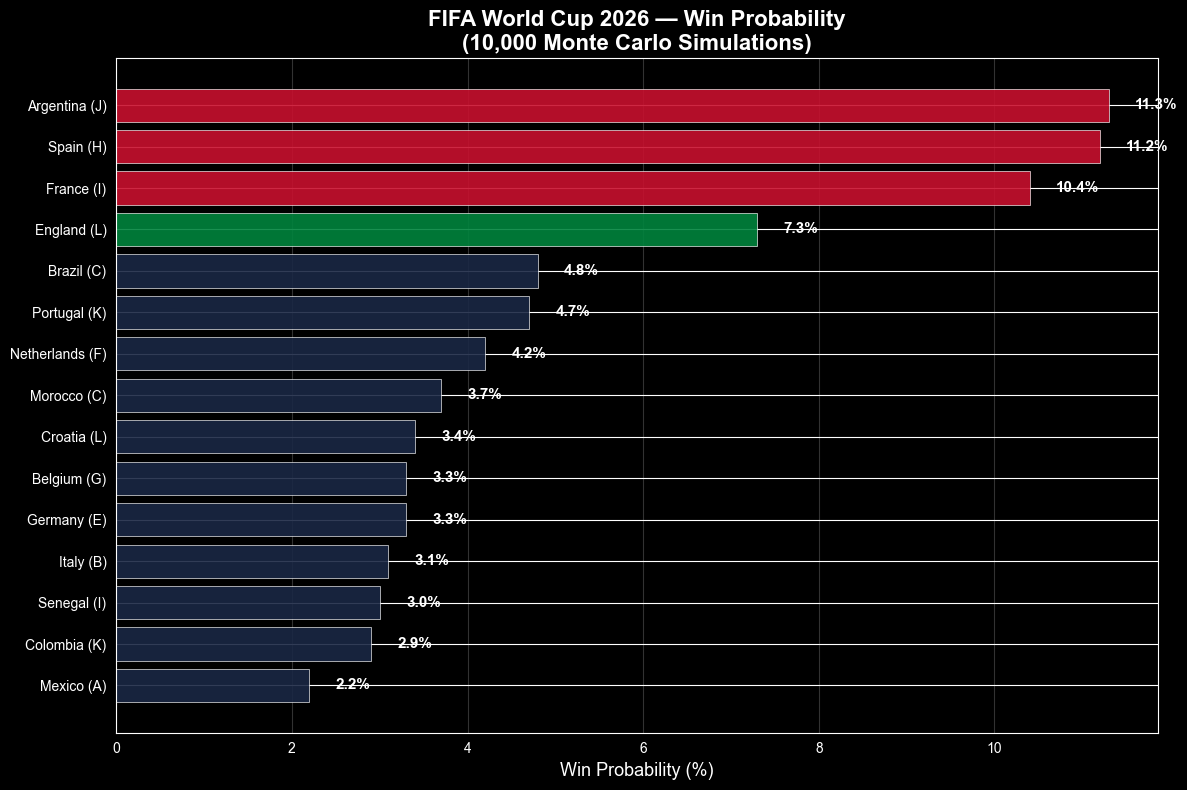

In [105]:
fig, ax = plt.subplots(figsize=(12, 8))

top15 = sim_df.head(15)
colors = ['#c8102e' if w >= 10 else '#00843d' if w >= 5 else '#1a2744' for w in top15['Winner']]

bars = ax.barh(range(len(top15)), top15['Winner'], color=colors, alpha=0.9, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels([f"{row['team']} ({row['Grp']})" for _, row in top15.iterrows()])
ax.invert_yaxis()
ax.set_xlabel('Win Probability (%)', fontsize=13)
ax.set_title(f'FIFA World Cup 2026 — Win Probability\n({N_SIMS:,} Monte Carlo Simulations)', fontsize=16, fontweight='bold')
ax.grid(axis='x', alpha=0.2)

for i, (_, row) in enumerate(top15.iterrows()):
    ax.text(row['Winner'] + 0.3, i, f"{row['Winner']:.1f}%", va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/14_tournament_win_probabilities.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.2 Stage-by-Stage Progression — Top 10


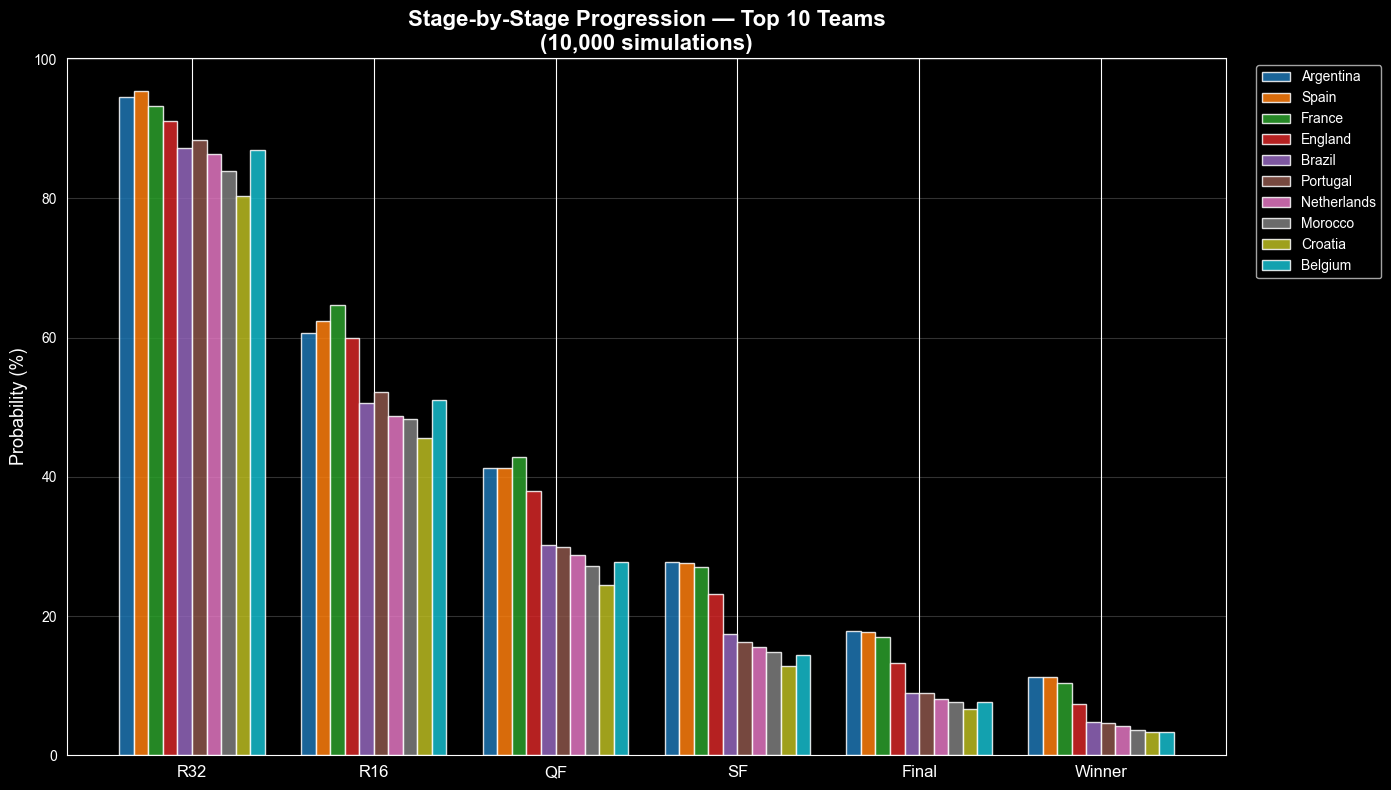

In [106]:
fig, ax = plt.subplots(figsize=(14, 8))

top10 = sim_df.head(10)
stages_plot = ["R32", "R16", "QF", "SF", "Final", "Winner"]
x = np.arange(len(stages_plot))
width = 0.08
team_colors = plt.cm.tab10(np.linspace(0, 1, 10))

for i, (_, row) in enumerate(top10.iterrows()):
    values = [row[s] for s in stages_plot]
    ax.bar(x + i * width, values, width, label=row['team'], color=team_colors[i], alpha=0.85)

ax.set_xticks(x + width * 4.5)
ax.set_xticklabels(stages_plot, fontsize=12)
ax.set_ylabel('Probability (%)', fontsize=13)
ax.set_title(f'Stage-by-Stage Progression — Top 10 Teams\n({N_SIMS:,} simulations)', fontsize=16, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('../outputs/figures/15_stage_progression.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.3 Group-by-Group Qualification Rates


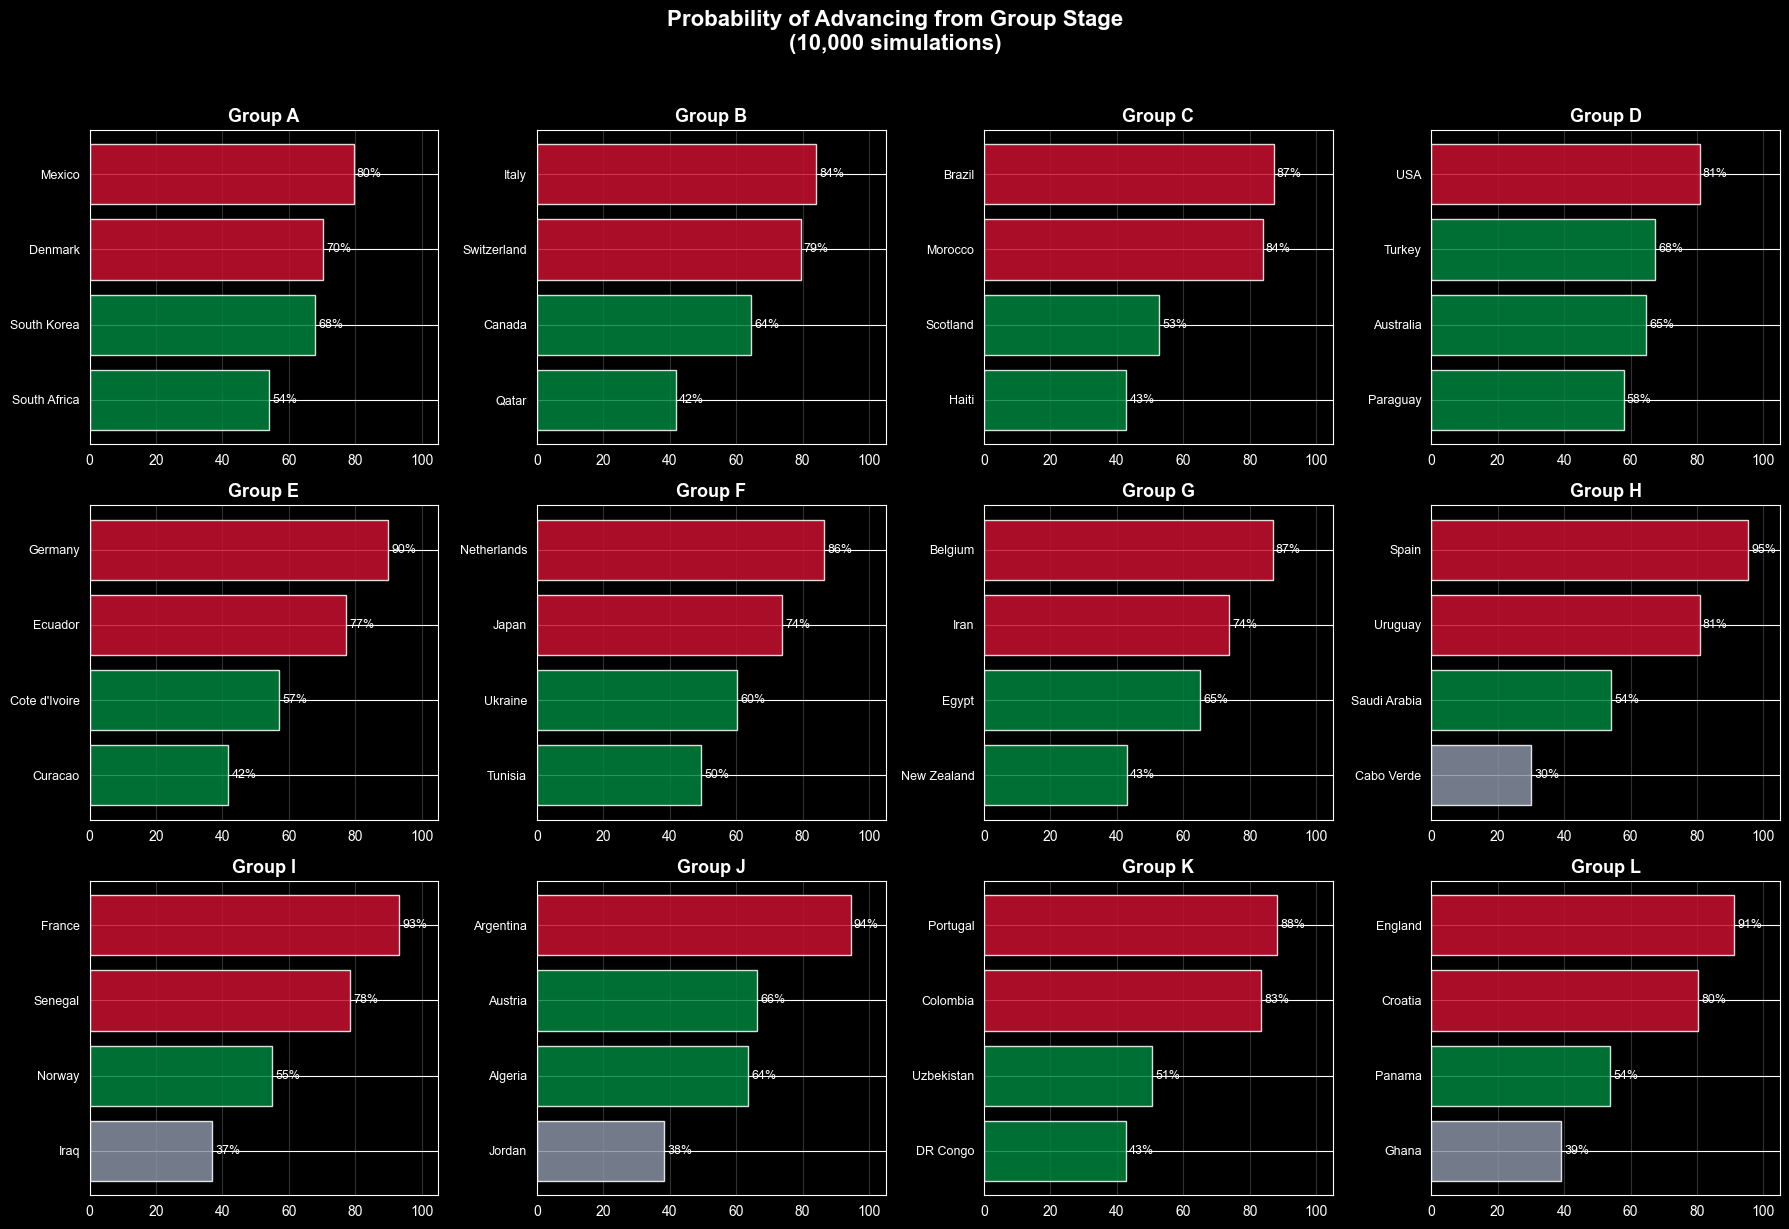

In [107]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, (group_name, teams) in enumerate(GROUPS.items()):
    ax = axes[idx]
    
    team_data = sim_df[sim_df['team'].isin(teams)].sort_values('R32', ascending=True)
    colors = ['#c8102e' if r >= 70 else '#00843d' if r >= 40 else '#8892a4' for r in team_data['R32']]
    
    ax.barh(range(len(team_data)), team_data['R32'], color=colors, alpha=0.85)
    ax.set_yticks(range(len(team_data)))
    ax.set_yticklabels(team_data['team'], fontsize=9)
    ax.set_title(f'Group {group_name}', fontsize=13, fontweight='bold')
    ax.set_xlim(0, 105)
    ax.grid(axis='x', alpha=0.2)
    
    for i, (_, row) in enumerate(team_data.iterrows()):
        ax.text(row['R32'] + 1, i, f"{row['R32']:.0f}%", va='center', fontsize=9)

fig.suptitle(f'Probability of Advancing from Group Stage\n({N_SIMS:,} simulations)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/16_group_qualification_rates.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Export Results


In [108]:
# Export to CSV
export_cols = ["team", "Grp", "Elo", "R32", "R16", "QF", "SF", "Final", "Winner"]
sim_df[["team", "Grp", "Elo", "R32", "R16", "QF", "SF", "Final", "Winner"]].to_csv(
    '../data/processed/simulation_results.csv', index=True
)

# Export to JSON (for React dashboard)
import json
dashboard_data = []
for _, row in sim_df.iterrows():
    dashboard_data.append({
        "team": row["team"],
        "group": row["Grp"],
        "elo": int(row["Elo"]) if pd.notna(row["Elo"]) else 1400,
        "r32": round(row["R32"], 1),
        "r16": round(row["R16"], 1),
        "qf": round(row["QF"], 1),
        "sf": round(row["SF"], 1),
        "final": round(row["Final"], 1),
        "winner": round(row["Winner"], 1),
    })

with open('../data/processed/simulation_results.json', 'w') as f:
    json.dump(dashboard_data, f, indent=2)

print(f"✅ Exported simulation results")
print(f"   → data/processed/simulation_results.csv")
print(f"   → data/processed/simulation_results.json")
print(f"   → Ready for React dashboard integration")


✅ Exported simulation results
   → data/processed/simulation_results.csv
   → data/processed/simulation_results.json
   → Ready for React dashboard integration


## 7. Key Insights

### Top Contenders
Based on the Monte Carlo simulation, the most likely World Cup winners are determined by a combination of team strength (Elo rating), group difficulty, and bracket path.

### Group of Death
**Group I** (Iraq, France, Senegal, Norway) is brutal — even France faces a realistic chance of early elimination. Group K (DR Congo, Portugal, Uzbekistan, Colombia) is also tough.

### Bracket Advantage
Teams on opposite sides of the bracket face different paths to the final. Some teams benefit from an easier projected bracket path despite having similar strength ratings.

### Methodology Notes
- 10,000 simulations provide stable estimates (standard error < 0.5% for top teams)
- Match outcomes are probabilistic based on FIFA Elo ratings
- Group tiebreakers follow FIFA rules: points → GD → GF → random
- Knockout matches have compressed probabilities (0.85 factor) to account for extra time/penalties randomness
- 3rd-place advancement uses the official 8-best-of-12 system

### Next Steps
- Integrate results into the React dashboard (Simulator tab)
- Add a Match Predictor tab where users can select any two teams
- Deploy to Vercel
